# Optimal Transport in linear ICA

#### Try to find a case where the FastICA assumption $E(XG’(X)-G’’(X))!=0$ where G is a contrast function (logcosh), does not hold and OT ICA performs. 

### Engineering a Mathematical Trap for FastICA (Assumption A.5)

To mathematically prove the limitations of FastICA's reliance on parametric summaries, we can engineer a specific distribution that violates its core convergence requirement, known as **Assumption A.5**. 

Assumption A.5 requires that the generalized kurtosis for the chosen contrast function $g(s)$ must not be zero:
$$E[s g(s) - g'(s)] \neq 0$$

For FastICA's default `logcosh` contrast function, the derivatives are $g(s) = \tanh(s)$ and $g'(s) = 1 - \tanh^2(s)$. We want to find a distribution where this expectation is exactly $0$.

#### 1. Defining the Discrete Distribution
We define a symmetric discrete distribution that takes only three values $S \in \{-b, 0, b\}$ with corresponding probabilities $\{p, 1-2p, p\}$.

#### 2. The Unit Variance Constraint
Standard ICA requires the independent sources to have unit variance ($E[S^2] = 1$). 
$$E[S^2] = p(-b)^2 + (1-2p)(0)^2 + p(b)^2 = 2pb^2$$
Setting this to $1$, we can express the probability $p$ entirely in terms of the value $b$:
$$p = \frac{1}{2b^2}$$

#### 3. Forcing the A.5 Failure Condition
We substitute our discrete distribution into the FastICA failure condition $E[s \tanh(s) - (1 - \tanh^2(s))] = 0$:

$$2p \left[ b \tanh(b) - (1 - \tanh^2(b)) \right] + (1-2p) \left[ 0 - (1 - 0) \right] = 0$$

Simplifying the equation:
$$2p \left[ b \tanh(b) - 1 + \tanh^2(b) \right] - (1 - 2p) = 0$$
$$2p \left[ b \tanh(b) + \tanh^2(b) \right] - 2p - 1 + 2p = 0$$
$$2p \left[ b \tanh(b) + \tanh^2(b) \right] = 1$$

#### 4. The Final Root Equation
Substituting $2p = \frac{1}{b^2}$ into the simplified equation yields a single-variable root-finding problem:
$$\frac{1}{b^2} \left[ b \tanh(b) + \tanh^2(b) \right] = 1$$
$$b \tanh(b) + \tanh^2(b) - b^2 = 0$$

By solving for $b$ numerically, we find the exact signal amplitude (and corresponding probability $p$) that makes the data mathematically invisible to FastICA's Newton-step optimizer.

In [17]:
import numpy as np
import torch
import pandas as pd
import time
from sklearn.decomposition import FastICA
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.optimize import root_scalar
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

from wasserstein_ica import WassersteinICA

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Define a consistent Thesis Theme
def set_thesis_theme():
    # Academic, colorblind-friendly palette
    # Blue, Orange, Green, Red, Purple, Brown
    thesis_colors = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']
    
    mpl.rcParams.update({
        # Figure and Layout
        'figure.figsize': (8, 5),
        'figure.dpi': 300,            # High resolution for print
        'axes.prop_cycle': mpl.cycler(color=thesis_colors),
        
        # Grid lines (light and unobtrusive)
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linestyle': '--',
        'axes.axisbelow': True,       # Grid goes behind data
        
        # Spines (remove top and right borders for a cleaner look)
        'axes.spines.top': False,
        'axes.spines.right': False,
        
        # Fonts and Text
        'font.size': 11,
        'axes.titlesize': 13,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        
        # Legends
        'legend.frameon': False,      # No box around the legend
        'legend.fontsize': 10,
        
        # Lines
        'lines.linewidth': 2.0
    })

# Run this before plotting
set_thesis_theme()

In [3]:
# ==========================================
# 1. The Mathematical Trap Generator
# ==========================================

def find_fastica_trap_b():
    """Finds the exact value of b that makes generalized kurtosis 0 for logcosh."""
    def target_func(b):
        return b * np.tanh(b) + np.tanh(b)**2 - b**2
    
    # We know the root is somewhere between 1.0 and 2.0
    sol = root_scalar(target_func, bracket=[1.0, 2.0], method='brentq')
    return sol.root

# Calculate our fastica trap parameters
MAGIC_B = find_fastica_trap_b()
MAGIC_P = 1.0 / (2 * MAGIC_B**2)
print(f"Calculated Trap Value b: {MAGIC_B:.5f}")
print(f"Calculated Probability p: {MAGIC_P:.5f}")

Calculated Trap Value b: 1.44891
Calculated Probability p: 0.23817


In [19]:
def generate_discrete_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # Generate the source signals based on our exact probabilities
    # Choices: -b, 0, b. Probabilities: p, 1-2p, p
    choices = [-MAGIC_B, 0.0, MAGIC_B]
    probs = [MAGIC_P, 1.0 - 2*MAGIC_P, MAGIC_P]
    
    sources = []
    for _ in range(n_dim):
        s = np.random.choice(choices, size=n_samples, p=probs)
        sources.append(s)
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

def amari_error(W_est, A_true):
    if W_est is None or np.any(np.isnan(W_est)):
        return np.nan
    P = np.abs(W_est @ A_true)
    n = P.shape[0]
    row_sum = np.sum(P, axis=1)
    row_max = np.max(P, axis=1)
    term1 = np.sum((row_sum / row_max) - 1)
    col_sum = np.sum(P, axis=0)
    col_max = np.max(P, axis=0)
    term2 = np.sum((col_sum / col_max) - 1)
    return (term1 + term2) / (2 * n)

In [5]:
# ==========================================
# 2. Parallel Worker Function
# ==========================================

def run_trap_trial(dim, trial, n_samples):
    torch.set_num_threads(1) 
    trial_results = []

    # Detect GPU inside the worker
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    X_torch, A_true = generate_discrete_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    
    # Pull back to CPU for Scikit-learn's FastICA
    X_np = X_torch.cpu().numpy()
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=2000, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true)
    except Exception as e:
        score_fast = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'FastICA', 'Amari Error': score_fast})
    
# --- W-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        n_restarts = dim * 4 if dim * 4 < 150 else 150
        
        # Phase 1: Deflation (incorporating dithering for discrete sources)
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=200, 
                n_restarts=n_restarts,
                dither_sigma=0.01  # Added to smooth discrete step-functions in CDF
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # Phase 2: Symmetric Stiefel Optimization (incorporating stochastic mini-batching)
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=400,        # Increased from 200 for complex landscape settling time
            lr=0.25,             # Halved from 0.5 to ensure stability with stochastic updates
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   # Maintains gradient smoothness across discrete gaps
            batch_size=1024      # Introduces stochasticity to escape spurious local maxima
        )
        
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({'Dimension': dim, 'Method': 'W-ICA (Stiefel)', 'Amari Error': score_wass})
    
    return trial_results

In [6]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = list(range(5, 26, 5))
N_SAMPLES = 10000
N_TRIALS = 5

print(f"--- FastICA Assumption A.5 Trap Showdown ---")

tasks = [(dim, trial, N_SAMPLES) for dim in DIMENSIONS for trial in range(N_TRIALS)]

results_nested = Parallel(n_jobs=12, return_as="generator")(
    delayed(run_trap_trial)(dim, trial, n_samples) 
    for dim, trial, n_samples in tqdm(tasks, desc="Running Trap Trials")
)

results = [item for sublist in results_nested for item in sublist]
df = pd.DataFrame(results)

--- FastICA Assumption A.5 Trap Showdown ---


Running Trap Trials:   0%|          | 0/25 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  war

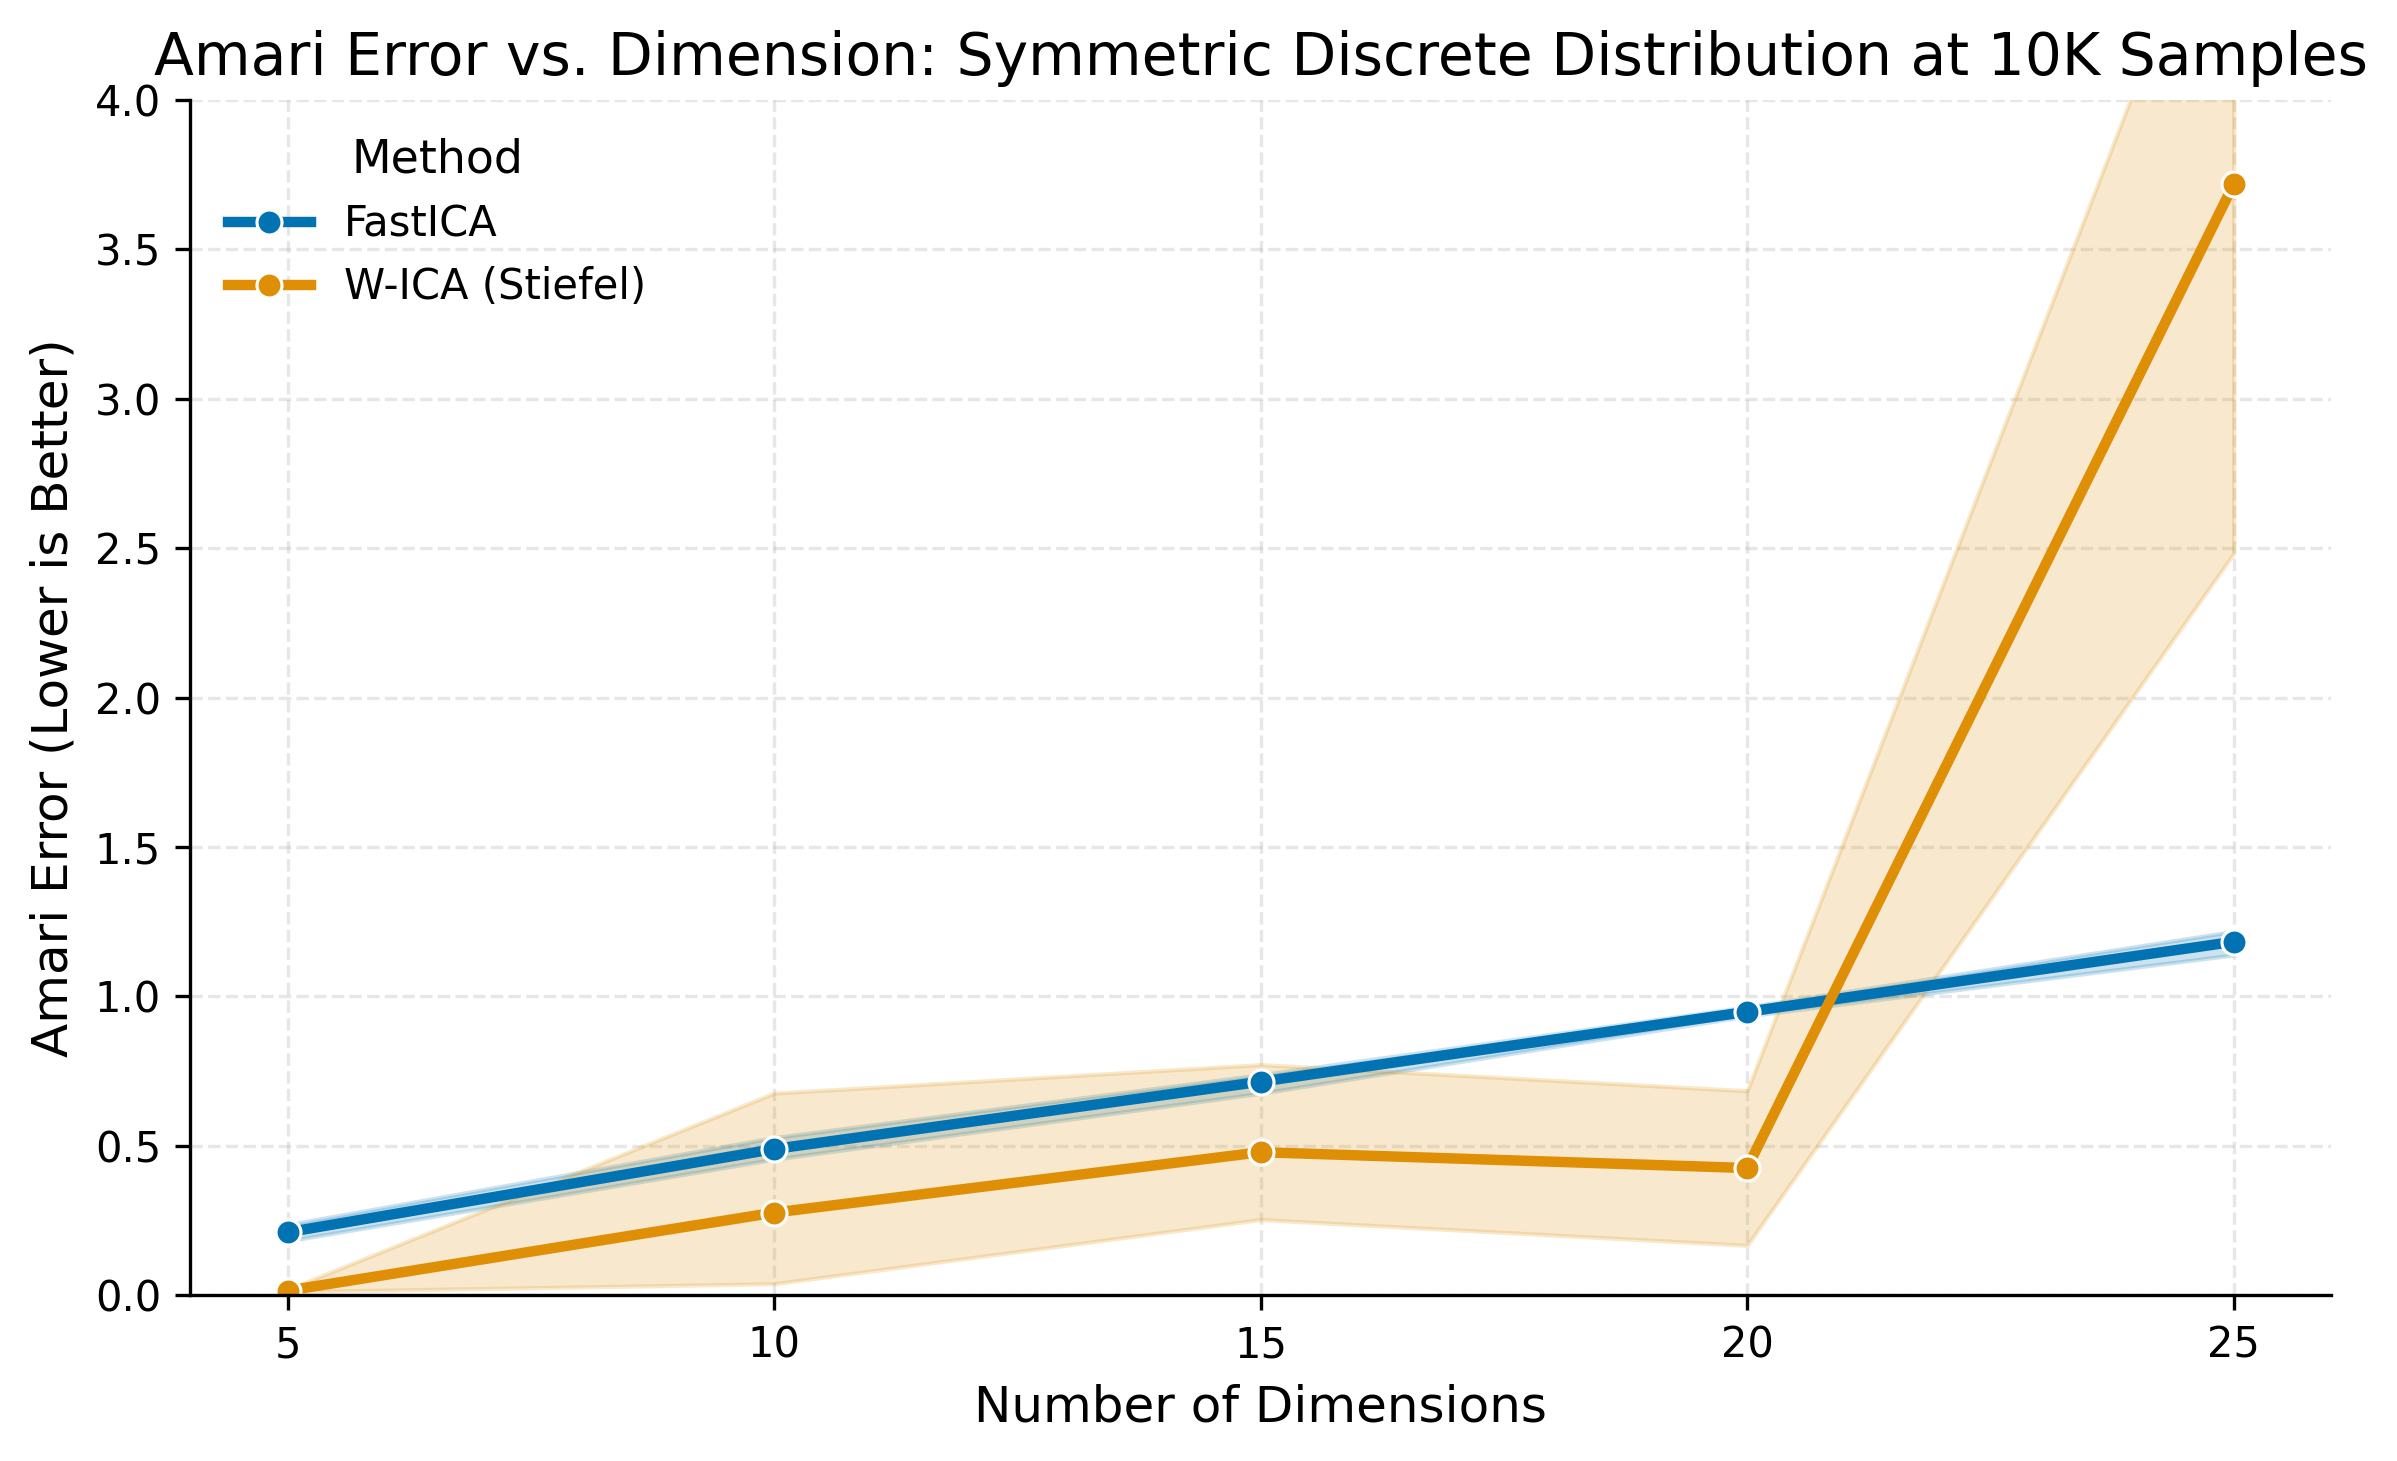

Method,FastICA,W-ICA (Stiefel)
Dimension,,
5,0.2104,0.0152
10,0.4891,0.2761
15,0.7144,0.4785
20,0.9483,0.4255
25,1.1827,3.7185


In [7]:
# ==========================================
# 4. Plotting the Results
# ==========================================
plt.figure(figsize=(8, 5))
sns.lineplot(data=df, x='Dimension', y='Amari Error', hue='Method', marker='o', linewidth=2.5)
plt.title("Amari Error vs. Dimension: Symmetric Discrete Distribution at 10K Samples", fontsize=14)
plt.ylabel("Amari Error (Lower is Better)", fontsize=12)
plt.xlabel("Number of Dimensions", fontsize=12)
plt.xticks(DIMENSIONS)
plt.ylim(0, 4)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

#plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(df.groupby(['Dimension', 'Method'])['Amari Error'].mean().unstack().round(4))

### Engineering the Trimodal Gaussian  (The "Smoothed" Discrete Trap)

To break FastICA's Assumption A.5 while maintaining a continuous probability density for Optimal Transport, we use a **Trimodal Gaussian Mixture**. This acts as a continuous, smoothed version of our successful discrete trap.

#### 1. Defining the Trimodal Distribution
We place three Gaussian peaks at $-b$, $0$, and $b$. To smooth the distribution, we give each peak a small, constant variance of $\sigma^2$. 
The mixture is defined by probabilities $p$, $1-2p$, and $p$.

#### 2. The Unit Variance Constraint
The variance of this mixture is the sum of the discrete variance and the continuous Gaussian variance:
$$E[S^2] = 2pb^2 + \sigma^2$$
To enforce unit variance ($E[S^2] = 1$), we fix our smoothing factor (e.g., $\sigma = 0.15$) and express the probability $p$ entirely in terms of the peak location $b$:
$$p = \frac{1 - \sigma^2}{2b^2}$$

#### 3. Forcing the A.5 Failure Condition
We define the FastICA target function $h(x) = x \tanh(x) - 1 + \tanh^2(x)$.
The expected value $E[h(S)]$ must equal exactly zero. Because the signal is now a continuous mixture of three Gaussians, the expectation is the integral of $h(x)$ multiplied by the combined Probability Density Function (PDF):

$$PDF(x) = p \cdot \phi(x; -b, \sigma) + (1-2p) \cdot \phi(x; 0, \sigma) + p \cdot \phi(x; b, \sigma)$$
$$\int_{-\infty}^{\infty} h(x) \cdot PDF(x) dx = 0$$

By solving this integral numerically for $b$, we find the exact spacing of the peaks that mathematically blinds FastICA's Newton optimizer while providing continuous gradients for W-ICA.

In [20]:
from scipy.integrate import quad

In [21]:
# ==========================================
# 1. The Trimodal Trap Generator
# ==========================================

def find_trimodal_trap_params(sigma=0.15):
    """Finds the optimal b for the Trimodal Gaussian A.5 trap."""
    def h(x):
        return x * np.tanh(x) - 1.0 + np.tanh(x)**2
        
    def target_func(b):
        p = (1.0 - sigma**2) / (2 * b**2)
        
        def pdf(x):
            norm_const = 1.0 / (np.sqrt(2 * np.pi) * sigma)
            term1 = p * np.exp(-0.5 * ((x + b) / sigma)**2)
            term2 = (1 - 2*p) * np.exp(-0.5 * (x / sigma)**2)
            term3 = p * np.exp(-0.5 * ((x - b) / sigma)**2)
            return norm_const * (term1 + term2 + term3)
            
        def integrand(x):
            return h(x) * pdf(x)
            
        # Integrate over a wide enough range to capture the tails
        integral_val, _ = quad(integrand, -10, 10)
        return integral_val

    # The discrete trap found a root near 1.5, so we bracket around there
    sol = root_scalar(target_func, bracket=[1.1, 2.0], method='brentq')
    b_opt = sol.root
    p_opt = (1.0 - sigma**2) / (2 * b_opt**2)
    return b_opt, p_opt, sigma

TRAP_B, TRAP_P, TRAP_SIGMA = find_trimodal_trap_params()
print(f"Calculated Peak Location (b): {TRAP_B:.5f}")
print(f"Calculated Edge Probability (p): {TRAP_P:.5f}")
print(f"Constant Smoothing (sigma): {TRAP_SIGMA:.5f}")

Calculated Peak Location (b): 1.44443
Calculated Edge Probability (p): 0.23426
Constant Smoothing (sigma): 0.15000


In [22]:
def generate_trimodal_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    # 1. Generate the discrete base
    choices = [-TRAP_B, 0.0, TRAP_B]
    probs = [TRAP_P, 1.0 - 2*TRAP_P, TRAP_P]
    
    sources = []
    for _ in range(n_dim):
        # Pick the discrete centers
        centers = np.random.choice(choices, size=n_samples, p=probs)
        # Add the continuous Gaussian noise
        noise = np.random.normal(0, TRAP_SIGMA, size=n_samples)
        sources.append(centers + noise)
        
    S = np.stack(sources)
    
    # Well-conditioned mixing matrix
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

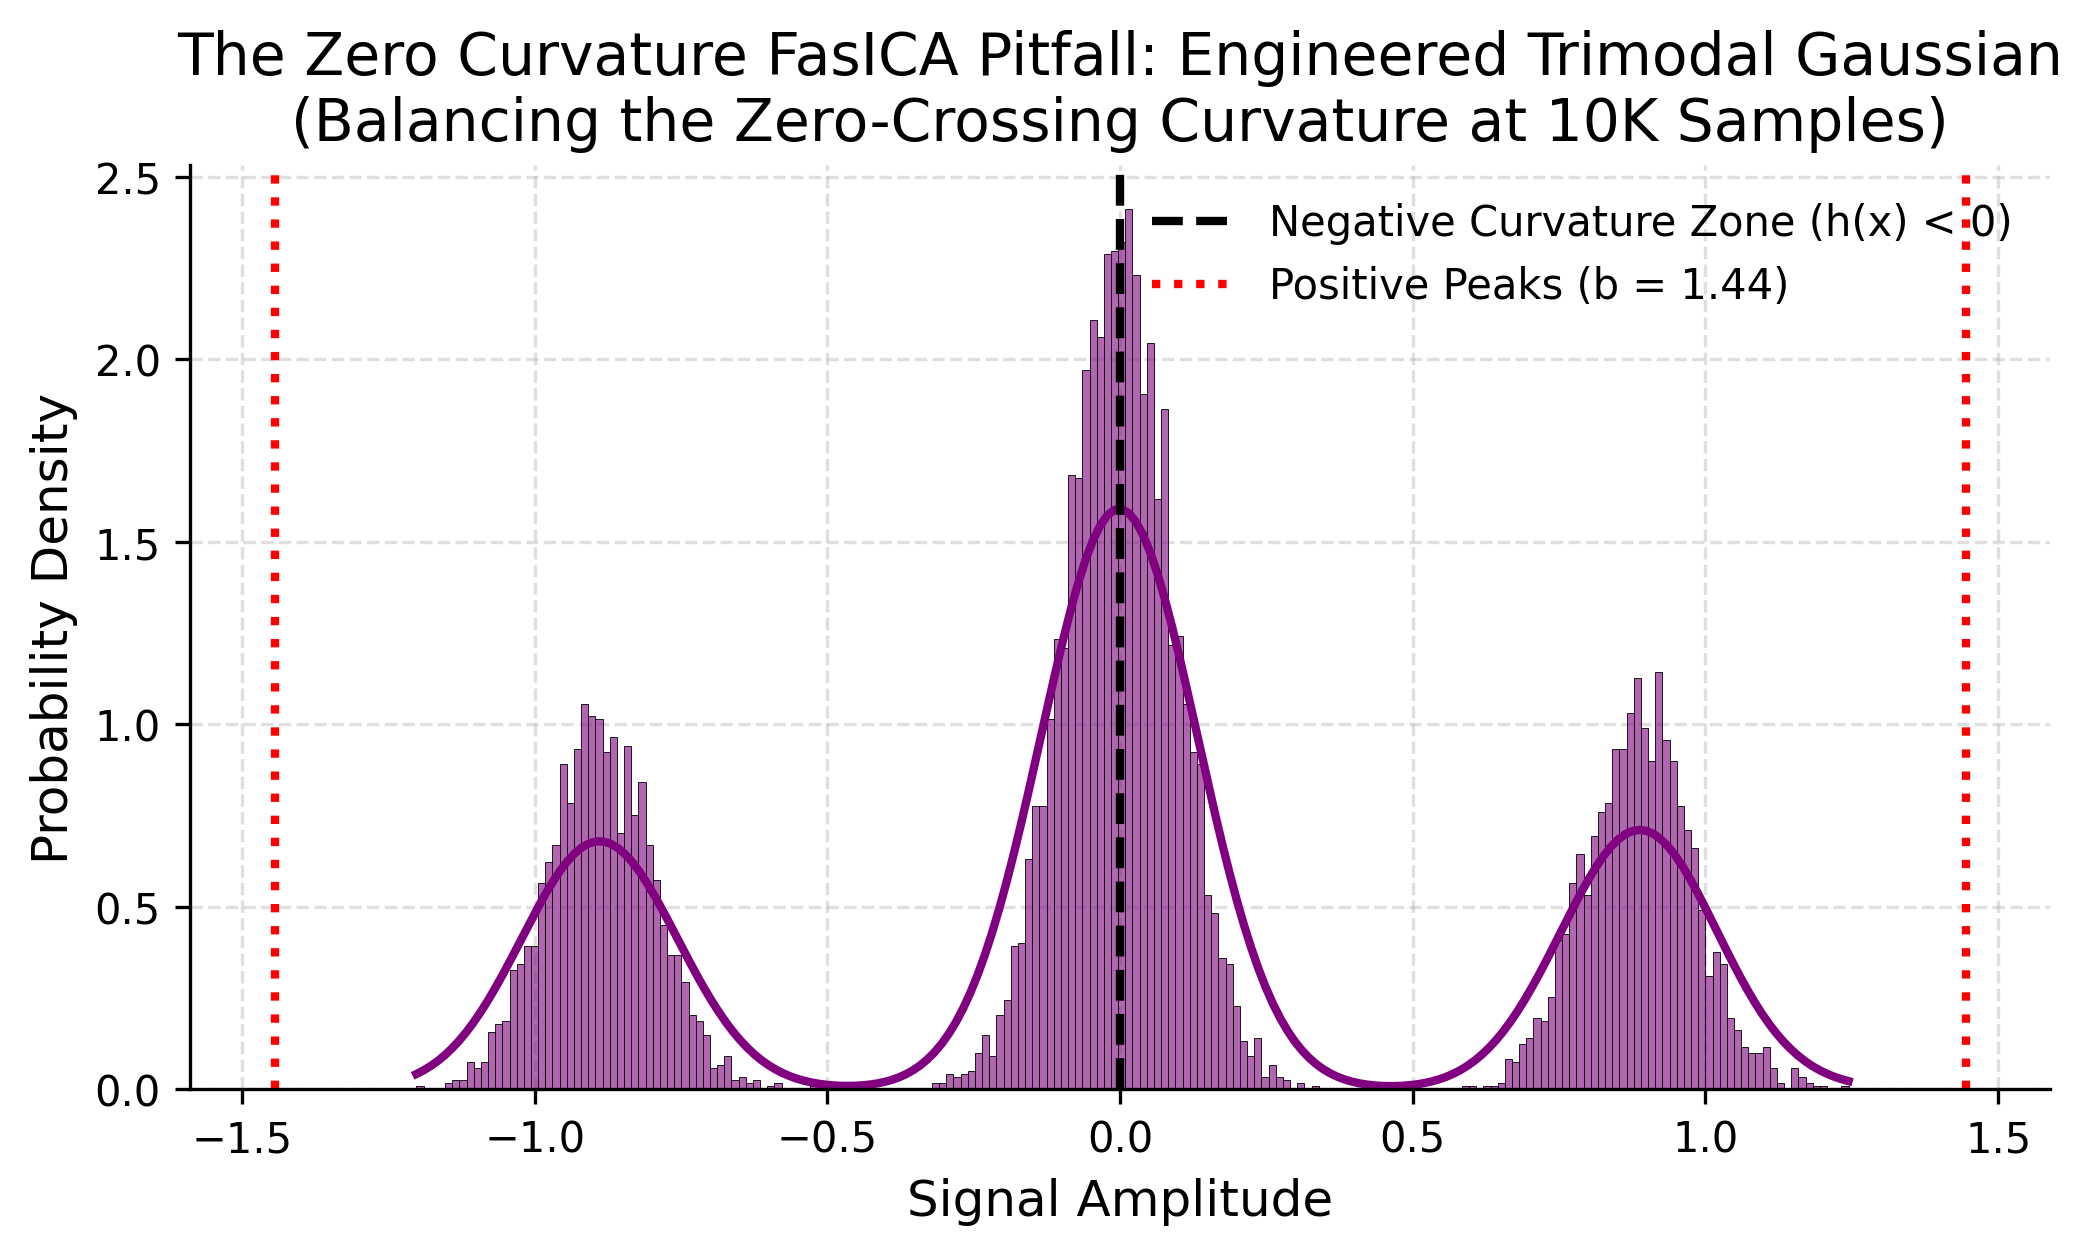

In [23]:
# Generate a 1-dimensional test sample to visualize the shape
test_samples, _ = generate_trimodal_trap(n_dim=1, n_samples=10000, seed=42)
test_np = test_samples.numpy().flatten()

plt.figure(figsize=(8, 4))
sns.histplot(test_np, bins=200, stat="density", color="purple", alpha=0.6, kde=True)

# Overlay the theoretical components to show the trap mechanics
plt.axvline(0, color='black', linestyle='--', label='Negative Curvature Zone (h(x) < 0)')
plt.axvline(-TRAP_B, color='red', linestyle=':', label=f'Positive Peaks (b = {TRAP_B:.2f})')
plt.axvline(TRAP_B, color='red', linestyle=':')

plt.title("The Zero Curvature FasICA Pitfall: Engineered Trimodal Gaussian\n(Balancing the Zero-Crossing Curvature at 10K Samples)", fontsize=14)
plt.xlabel("Signal Amplitude")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from joblib import Parallel, delayed
from tqdm import tqdm
from matplotlib.ticker import MultipleLocator
from sklearn.decomposition import FastICA
import warnings
from sklearn.exceptions import ConvergenceWarning

In [29]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================
def run_trimodal_trap_trial(dim, trial, compute_level):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_samples = 10000  # Fixed at 10K
    X_torch, A_true = generate_trimodal_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # Configure Compute Parameters
    if compute_level == 'Low Compute':
        fast_max_iter = 1000
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 150
        w2_sym_iter = 300
    else: # High Compute
        fast_max_iter = 10000 # Prove it oscillates infinitely
        w2_restarts = min(dim * 15, 600) # Massive parallel search
        w2_def_iter = 300
        w2_sym_iter = 800
    
    # --- FastICA ---
    try:
        fast_ica = FastICA(n_components=dim, max_iter=fast_max_iter, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true) 
    except Exception as e:
        print(f"FastICA Error (dim {dim}): {e}")
        score_fast = np.nan 
            
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_fast
    })
    
    # --- W2-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        
        # 1. Deflation Phase 
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=w2_def_iter, 
                n_restarts=w2_restarts,
                dither_sigma=0.01  
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 2. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=w2_sym_iter,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W2-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'W2-ICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_wass
    })
    
    return trial_results

In [30]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = list(range(5, 26, 5))
COMPUTE_LEVELS = ['Low Compute', 'High Compute']
N_TRIALS = 5

In [31]:
print(f"--- OT vs FastICA Trimodal Gaussian ---")

tasks = [(dim, trial, comp) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for comp in COMPUTE_LEVELS]

results_nested = []

with Parallel(n_jobs=12, return_as="generator") as parallel:
    jobs = (delayed(run_trimodal_trap_trial)(dim, trial, comp) for dim, trial, comp in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running Trimodal Trials"):
        results_nested.append(res)

results = [item for sublist in results_nested for item in sublist]
df_trimodal = pd.DataFrame(results)

--- OT vs FastICA Trimodal Gaussian ---


Running Trimodal Trials:   0%|          | 0/50 [00:00<?, ?it/s]/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider 

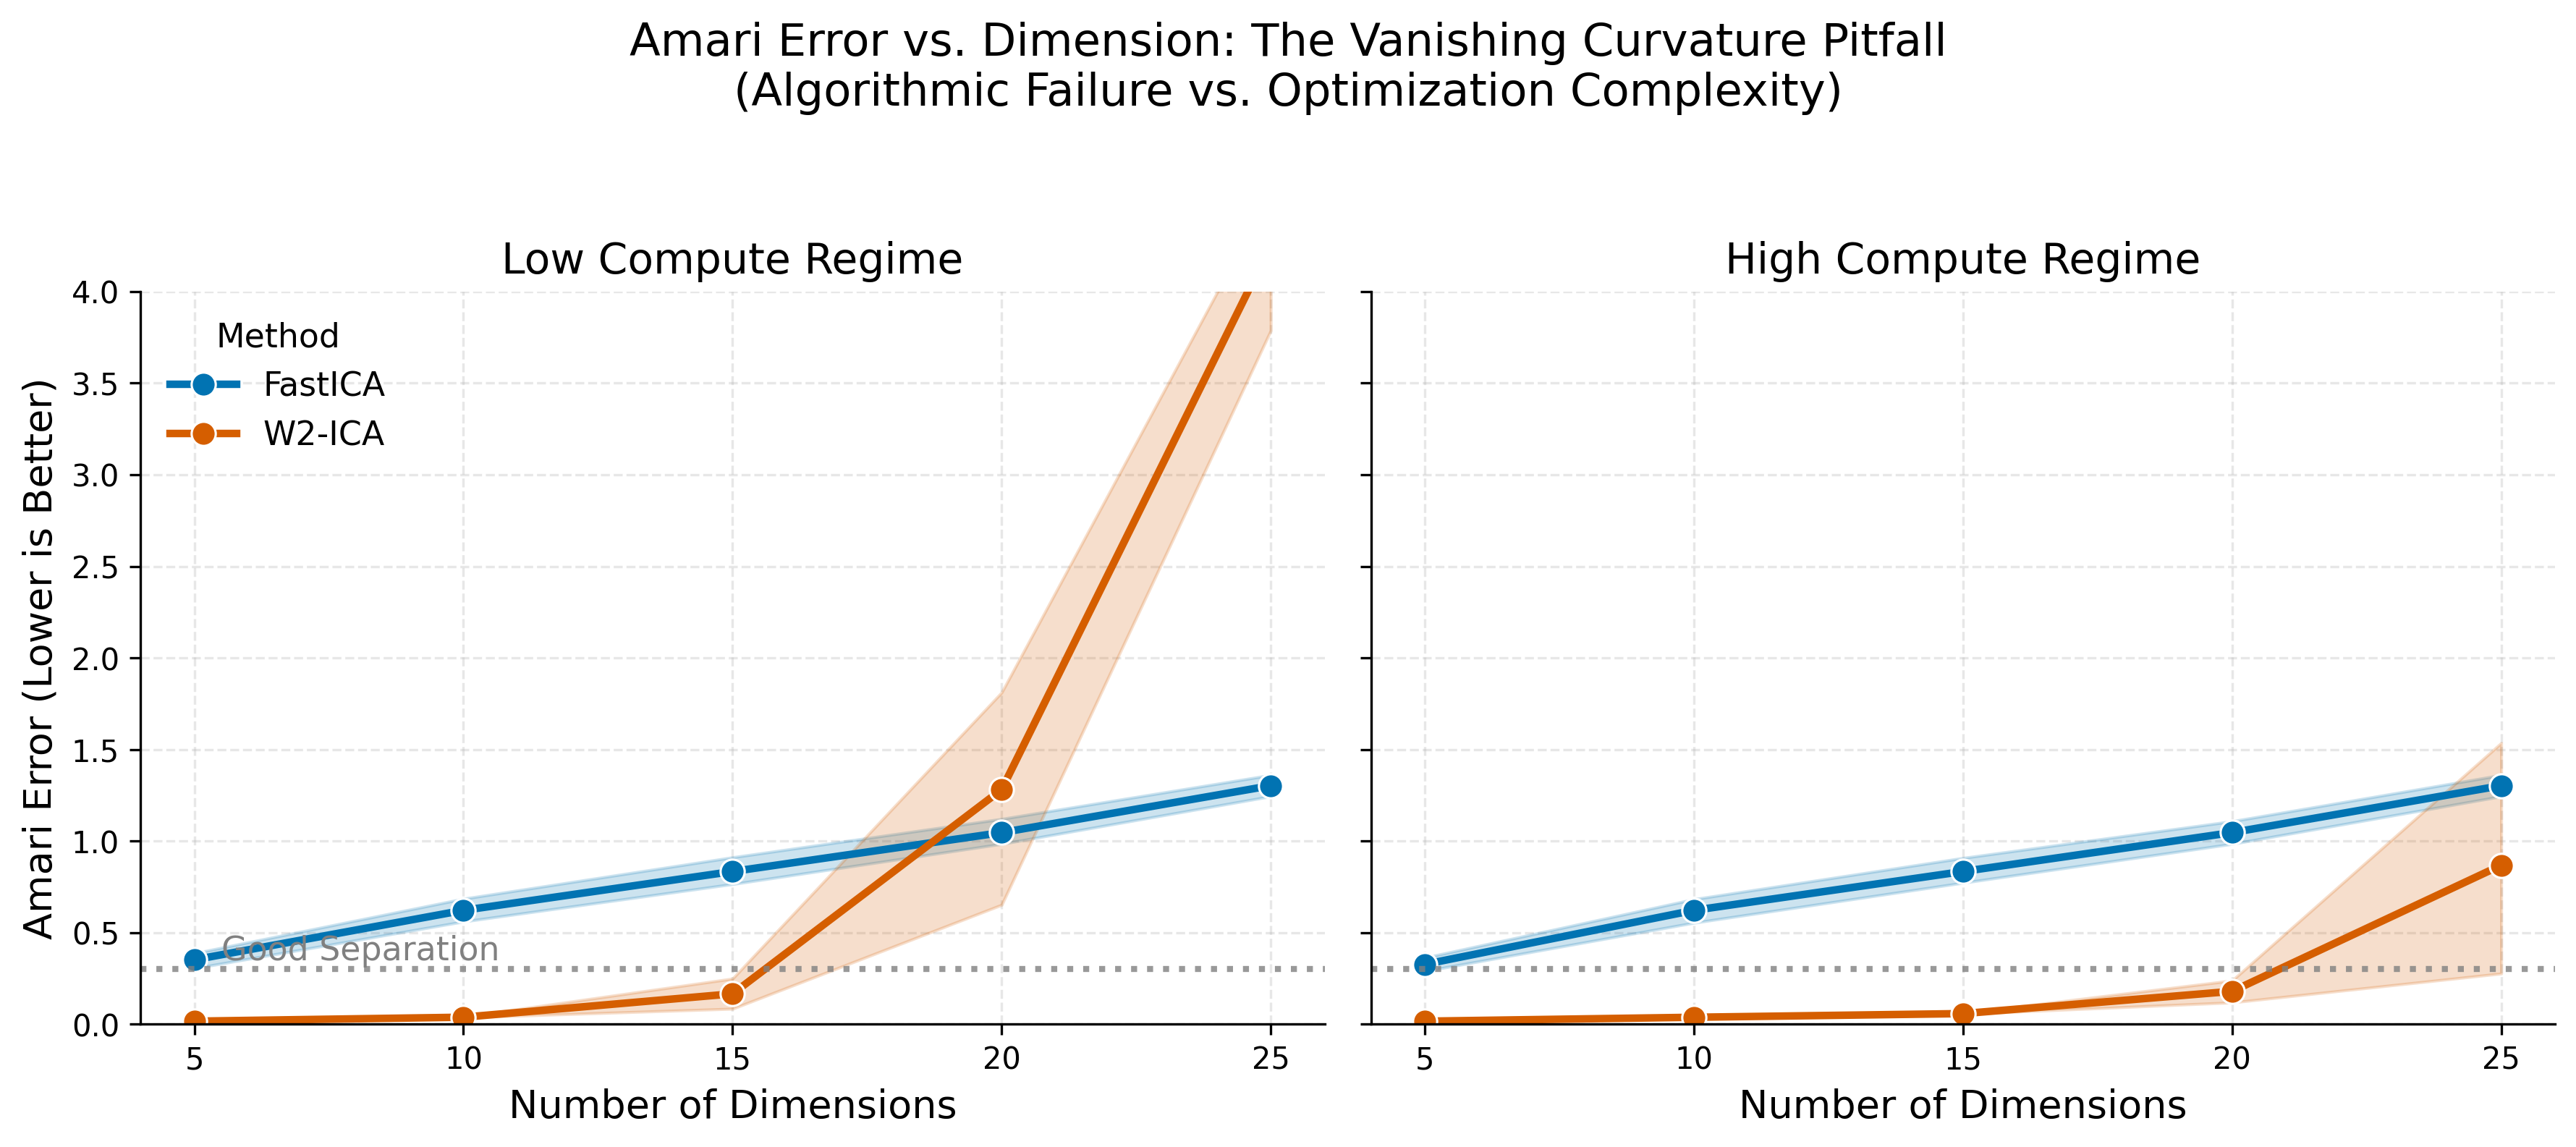

Method             FastICA                   W2-ICA            
Compute Level High Compute Low Compute High Compute Low Compute
Dimension                                                      
5                   0.3266      0.3516       0.0159      0.0159
10                  0.6213      0.6213       0.0373      0.0376
15                  0.8334      0.8334       0.0574      0.1655
20                  1.0459      1.0459       0.1790      1.2808
25                  1.3019      1.3019       0.8674      4.2520

In [33]:
# ==========================================
# 4. Plotting (Side-by-Side 1x2 Layout)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Updated Palette: FastICA is Blue, W2-ICA is Orange
palette = {'FastICA': '#0173B2', 'W2-ICA': '#D55E00'}

# --- Subplot 1: Low Compute ---
df_low = df_trimodal[df_trimodal['Compute Level'] == 'Low Compute']
sns.lineplot(
    data=df_low, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title("Low Compute Regime", fontsize=14)
axes[0].set_ylabel("Amari Error (Lower is Better)", fontsize=13)
axes[0].set_xlabel("Number of Dimensions", fontsize=13)
axes[0].set_xticks(DIMENSIONS)
axes[0].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)
axes[0].text(5.5, 0.35, 'Good Separation', color='gray', fontsize=11)

# Clean up legend for left plot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title='Method', loc='upper left', fontsize=11)

# --- Subplot 2: High Compute ---
df_high = df_trimodal[df_trimodal['Compute Level'] == 'High Compute']
sns.lineplot(
    data=df_high, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)
axes[1].set_title("High Compute Regime", fontsize=14)
axes[1].set_ylabel("") # Y-axis label is shared and handled by the left plot
axes[1].set_xlabel("Number of Dimensions", fontsize=13)
axes[1].set_xticks(DIMENSIONS)
axes[1].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)

# Remove redundant legend on the right plot
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# --- Global Formatting ---
plt.ylim(0, 4)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5))

fig.suptitle("Amari Error vs. Dimension: The Vanishing Curvature Pitfall\n(Algorithmic Failure vs. Optimization Complexity)", fontsize=15, y=1.05)

plt.tight_layout()
plt.savefig('vanishing_curvature_amari_compute.png', dpi=300, bbox_inches='tight')
plt.show()

# Display summary table
summary_table = df_trimodal.groupby(['Dimension', 'Method', 'Compute Level'])['Amari Error'].mean().unstack(level=[1,2]).round(4)
display(summary_table)

### Engineering the Adjusted Clipped Uniform (Assumption A.5)

By decoupling the boundary probability mass from a strict mathematical clipping operation, we create an **Adjusted Clipped Uniform Mixture**. This solves the variance paradox that previously made the continuous uniform trap mathematically impossible.

#### 1. Defining the Adjusted Mixture
We define the signal $S$ as a mixture of two components:
* A continuous uniform distribution on the interval $[-b, b]$ carrying a total probability mass of $1 - 2p$.
* Two Dirac delta spikes at the exact boundaries $-b$ and $b$, each carrying a tunable probability mass of $p$.

#### 2. The Unit Variance Constraint
To satisfy standard ICA scaling ($E[S^2] = 1$), the variance of the combined mixture must equal exactly 1:
$$E[S^2] = (1 - 2p) \int_{-b}^{b} x^2 \frac{1}{2b} dx + 2p b^2 = 1$$

Evaluating the integral for the continuous uniform portion yields:
$$(1 - 2p) \frac{b^2}{3} + 2p b^2 = 1$$

We algebraically isolate $p$ to express the required Dirac probability entirely as a function of the boundary $b$:
$$p = \frac{3 - b^2}{4b^2}$$
*(Note: To keep the probability valid, $p \in (0, 0.5)$, the boundary must fall within the range $1 < b < \sqrt{3}$.)*

#### 3. Forcing the A.5 Failure Condition
We define the FastICA `logcosh` failure condition as $h(x) = x \tanh(x) - 1 + \tanh^2(x)$. To blind the Newton optimizer, the expected value across the entire mixture must equal exactly zero:
$$E[h(S)] = (1 - 2p) \int_{-b}^{b} h(x) \frac{1}{2b} dx + 2p h(b) = 0$$

By substituting our variance-constrained $p$ into this equation, we create a single-variable root-finding problem for $b$. Because we are no longer forcing massive tails to compensate for a narrow center, the negative center of the uniform distribution is allowed to perfectly counterbalance the positive Dirac edges.

In [16]:
"""
from scipy.optimize import root_scalar
from scipy.integrate import quad
import seaborn as sns
import matplotlib.pyplot as plt
"""

'\nfrom scipy.optimize import root_scalar\nfrom scipy.integrate import quad\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n'

In [17]:
"""
# ==========================================
# 1. The Adjusted Clipped Trap Generator
# ==========================================

def find_adjusted_clipped_params():
    
    def h(x):
        return x * np.tanh(x) - 1.0 + np.tanh(x)**2
        
    def target_func(b):
        # Enforce unit variance
        p = (3.0 - b**2) / (4.0 * b**2)
        
        # Continuous uniform integral part
        integral_val, _ = quad(h, 0, b)
        expected_continuous = ((1.0 - 2.0 * p) / b) * integral_val
        
        # Discrete edges part
        expected_discrete = 2.0 * p * h(b)
        
        return expected_continuous + expected_discrete

    # Search within the valid bounds for b (1 to sqrt(3))
    sol = root_scalar(target_func, bracket=[1.05, 1.73], method='brentq')
    b_opt = sol.root
    p_opt = (3.0 - b_opt**2) / (4.0 * b_opt**2)
    return b_opt, p_opt

ADJ_B, ADJ_P = find_adjusted_clipped_params()
print(f"Calculated Clipping Boundary (b): {ADJ_B:.5f}")
print(f"Calculated Dirac Edge Mass (p): {ADJ_P:.5f}")
print(f"Continuous Uniform Mass: {1.0 - 2*ADJ_P:.5f}")
"""

'\n# ==========================================\n# 1. The Adjusted Clipped Trap Generator\n# ==========================================\n\ndef find_adjusted_clipped_params():\n\n    def h(x):\n        return x * np.tanh(x) - 1.0 + np.tanh(x)**2\n\n    def target_func(b):\n        # Enforce unit variance\n        p = (3.0 - b**2) / (4.0 * b**2)\n\n        # Continuous uniform integral part\n        integral_val, _ = quad(h, 0, b)\n        expected_continuous = ((1.0 - 2.0 * p) / b) * integral_val\n\n        # Discrete edges part\n        expected_discrete = 2.0 * p * h(b)\n\n        return expected_continuous + expected_discrete\n\n    # Search within the valid bounds for b (1 to sqrt(3))\n    sol = root_scalar(target_func, bracket=[1.05, 1.73], method=\'brentq\')\n    b_opt = sol.root\n    p_opt = (3.0 - b_opt**2) / (4.0 * b_opt**2)\n    return b_opt, p_opt\n\nADJ_B, ADJ_P = find_adjusted_clipped_params()\nprint(f"Calculated Clipping Boundary (b): {ADJ_B:.5f}")\nprint(f"Calculated Dira

In [18]:
"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def h(x):
    return x * np.tanh(x) - 1.0 + np.tanh(x)**2

# The valid domain for b is (1, sqrt(3))
b_vals = np.linspace(1.01, 1.73, 100)
y_vals = []

for b in b_vals:
    p = (3.0 - b**2) / (4.0 * b**2)
    integral_val, _ = quad(h, 0, b)
    expected_continuous = ((1.0 - 2.0 * p) / b) * integral_val
    expected_discrete = 2.0 * p * h(b)
    y_vals.append(expected_continuous + expected_discrete)

plt.figure(figsize=(8, 4))
plt.plot(b_vals, y_vals, linewidth=2.5, color='red', label='E[h(S)]')
plt.axhline(0, color='black', linestyle='--', label='Target Zero Crossing (A.5 Trap)')
plt.title("Proof of Impossibility: Adjusted Clipped Uniform vs logcosh", fontsize=12)
plt.xlabel("Boundary Parameter (b)", fontsize=11)
plt.ylabel("Expected Value of Contrast Derivative", fontsize=11)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()
"""

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom scipy.integrate import quad\n\ndef h(x):\n    return x * np.tanh(x) - 1.0 + np.tanh(x)**2\n\n# The valid domain for b is (1, sqrt(3))\nb_vals = np.linspace(1.01, 1.73, 100)\ny_vals = []\n\nfor b in b_vals:\n    p = (3.0 - b**2) / (4.0 * b**2)\n    integral_val, _ = quad(h, 0, b)\n    expected_continuous = ((1.0 - 2.0 * p) / b) * integral_val\n    expected_discrete = 2.0 * p * h(b)\n    y_vals.append(expected_continuous + expected_discrete)\n\nplt.figure(figsize=(8, 4))\nplt.plot(b_vals, y_vals, linewidth=2.5, color=\'red\', label=\'E[h(S)]\')\nplt.axhline(0, color=\'black\', linestyle=\'--\', label=\'Target Zero Crossing (A.5 Trap)\')\nplt.title("Proof of Impossibility: Adjusted Clipped Uniform vs logcosh", fontsize=12)\nplt.xlabel("Boundary Parameter (b)", fontsize=11)\nplt.ylabel("Expected Value of Contrast Derivative", fontsize=11)\nplt.legend()\nplt.grid(True, alpha=0.5)\nplt.show()\n'

### E[logcosh(Gaussain)] == E[logcosh(Mixture)]

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
from scipy.optimize import root_scalar
from scipy.integrate import quad
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator
from sklearn.decomposition import FastICA
import warnings

In [35]:
# ==========================================
# 1. The Zero-Negentropy Trap Generator
# ==========================================
def g_func(x):
    return np.log(np.cosh(x))

def gaussian_integrand(x):
    return g_func(x) * norm.pdf(x)

GAUSSIAN_BASELINE, _ = quad(gaussian_integrand, -10, 10)

def find_zero_negentropy_params(sigma=0.15):
    """Finds the optimal b for the Zero-Negentropy trap."""
    def target_func(b):
        p = (1.0 - sigma**2) / (2 * b**2)
        
        def pdf(x):
            norm_const = 1.0 / (np.sqrt(2 * np.pi) * sigma)
            term1 = p * np.exp(-0.5 * ((x + b) / sigma)**2)
            term2 = (1 - 2*p) * np.exp(-0.5 * (x / sigma)**2)
            term3 = p * np.exp(-0.5 * ((x - b) / sigma)**2)
            return norm_const * (term1 + term2 + term3)
            
        def integrand(x):
            return g_func(x) * pdf(x)
            
        integral_val, _ = quad(integrand, -10, 10)
        return integral_val - GAUSSIAN_BASELINE

    sol = root_scalar(target_func, bracket=[1.1, 1.8], method='brentq')
    b_opt = sol.root
    p_opt = (1.0 - sigma**2) / (2 * b_opt**2)
    return b_opt, p_opt, sigma

TRAP_B, TRAP_P, TRAP_SIGMA = find_zero_negentropy_params()
print(f"Calculated Phantom Boundary (b): {TRAP_B:.5f}")
print(f"Calculated Phantom Edge Probability (p): {TRAP_P:.5f}")

def generate_phantom_trap(n_dim, n_samples, seed=None):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)
        
    choices = [-TRAP_B, 0.0, TRAP_B]
    probs = [TRAP_P, 1.0 - 2*TRAP_P, TRAP_P]
    
    sources = []
    for _ in range(n_dim):
        centers = np.random.choice(choices, size=n_samples, p=probs)
        noise = np.random.normal(0, TRAP_SIGMA, size=n_samples)
        sources.append(centers + noise)
        
    S = np.stack(sources)
    
    cond_num = 1000
    while cond_num > 100:
        A = np.random.randn(n_dim, n_dim)
        cond_num = np.linalg.cond(A)
        
    X = A @ S
    return torch.tensor(X, dtype=torch.float32), A

Calculated Phantom Boundary (b): 1.54340
Calculated Phantom Edge Probability (p): 0.20518


In [37]:
# ==========================================
# 2. Parallel Worker Function (GPU Enabled)
# ==========================================
def run_phantom_trial(dim, trial, compute_level):
    torch.set_num_threads(1) 
    trial_results = []
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    n_samples = 10000  # Fixed at 10K
    X_torch, A_true = generate_phantom_trap(n_dim=dim, n_samples=n_samples, seed=trial)
    X_torch = X_torch.to(device)
    X_np = X_torch.cpu().numpy()
    
    # Configure Compute Parameters
    if compute_level == 'Low Compute':
        fast_max_iter = 1000
        w2_restarts = min(dim * 4, 150)
        w2_def_iter = 150
        w2_sym_iter = 300
    else: # High Compute
        fast_max_iter = 10000 
        w2_restarts = min(dim * 15, 600) 
        w2_def_iter = 300
        w2_sym_iter = 800
    
    # --- FastICA ---
    try:
        # FastICA typically fails silently here due to zero gradient, not max iterations
        fast_ica = FastICA(n_components=dim, max_iter=fast_max_iter, tol=1e-4, random_state=trial)
        fast_ica.fit(X_np.T)
        W_fast_total = fast_ica.components_
        score_fast = amari_error(W_fast_total, A_true) 
    except Exception as e:
        print(f"FastICA Error (dim {dim}): {e}")
        score_fast = np.nan 
            
    trial_results.append({
        'Dimension': dim, 
        'Method': 'FastICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_fast
    })
    
    # --- W2-ICA (Stiefel) ---
    try:
        ica = WassersteinICA(X_torch)
        ica.whiten()
        W_white_np = ica.W_white.cpu().numpy()
        
        extracted_ws = []
        
        # 1. Deflation Phase 
        for _ in range(dim):
            prev = torch.stack(extracted_ws) if extracted_ws else None
            w, _ = ica.optimize_wasserstein2(
                prev_components=prev, 
                max_iter=w2_def_iter, 
                n_restarts=w2_restarts,
                dither_sigma=0.01  
            )
            extracted_ws.append(w)
            
        W_deflation_init = torch.stack(extracted_ws)
        
        # 2. Symmetric Stiefel Phase 
        W_stiefel_unmixed = ica.optimize_symmetric(
            n_components=dim, 
            max_iter=w2_sym_iter,        
            lr=0.25,             
            init_w=W_deflation_init, 
            optimizer='stiefel',
            use_sinkhorn=False,
            dither_sigma=0.01,   
            batch_size=1024      
        )
        W_wass_total = W_stiefel_unmixed.cpu().numpy() @ W_white_np
        score_wass = amari_error(W_wass_total, A_true)
        
    except Exception as e:
        print(f"W2-ICA Error (dim {dim}): {e}")
        score_wass = np.nan
        
    trial_results.append({
        'Dimension': dim, 
        'Method': 'W2-ICA', 
        'Compute Level': compute_level, 
        'Amari Error': score_wass
    })
    
    return trial_results

In [38]:
# ==========================================
# 3. Main Execution
# ==========================================
DIMENSIONS = list(range(5, 26, 5))
COMPUTE_LEVELS = ['Low Compute', 'High Compute']
N_TRIALS = 5

In [39]:
print(f"--- FastICA Phantom Gaussian (Zero-Negentropy Trap) Showdown ---")

tasks = [(dim, trial, comp) 
         for dim in DIMENSIONS 
         for trial in range(N_TRIALS) 
         for comp in COMPUTE_LEVELS]

results_nested = []

with Parallel(n_jobs=12, return_as="generator") as parallel:
    jobs = (delayed(run_phantom_trial)(dim, trial, comp) for dim, trial, comp in tasks)
    for res in tqdm(parallel(jobs), total=len(tasks), desc="Running Phantom Trials"):
        results_nested.append(res)

results = [item for sublist in results_nested for item in sublist]
df_phantom = pd.DataFrame(results)

--- FastICA Phantom Gaussian (Zero-Negentropy Trap) Showdown ---


Running Phantom Trials:   0%|          | 0/50 [00:00<?, ?it/s]

/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
/home/ajha/Downloads/temp_mt/ot_in_linear_ica/wica_env/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  war

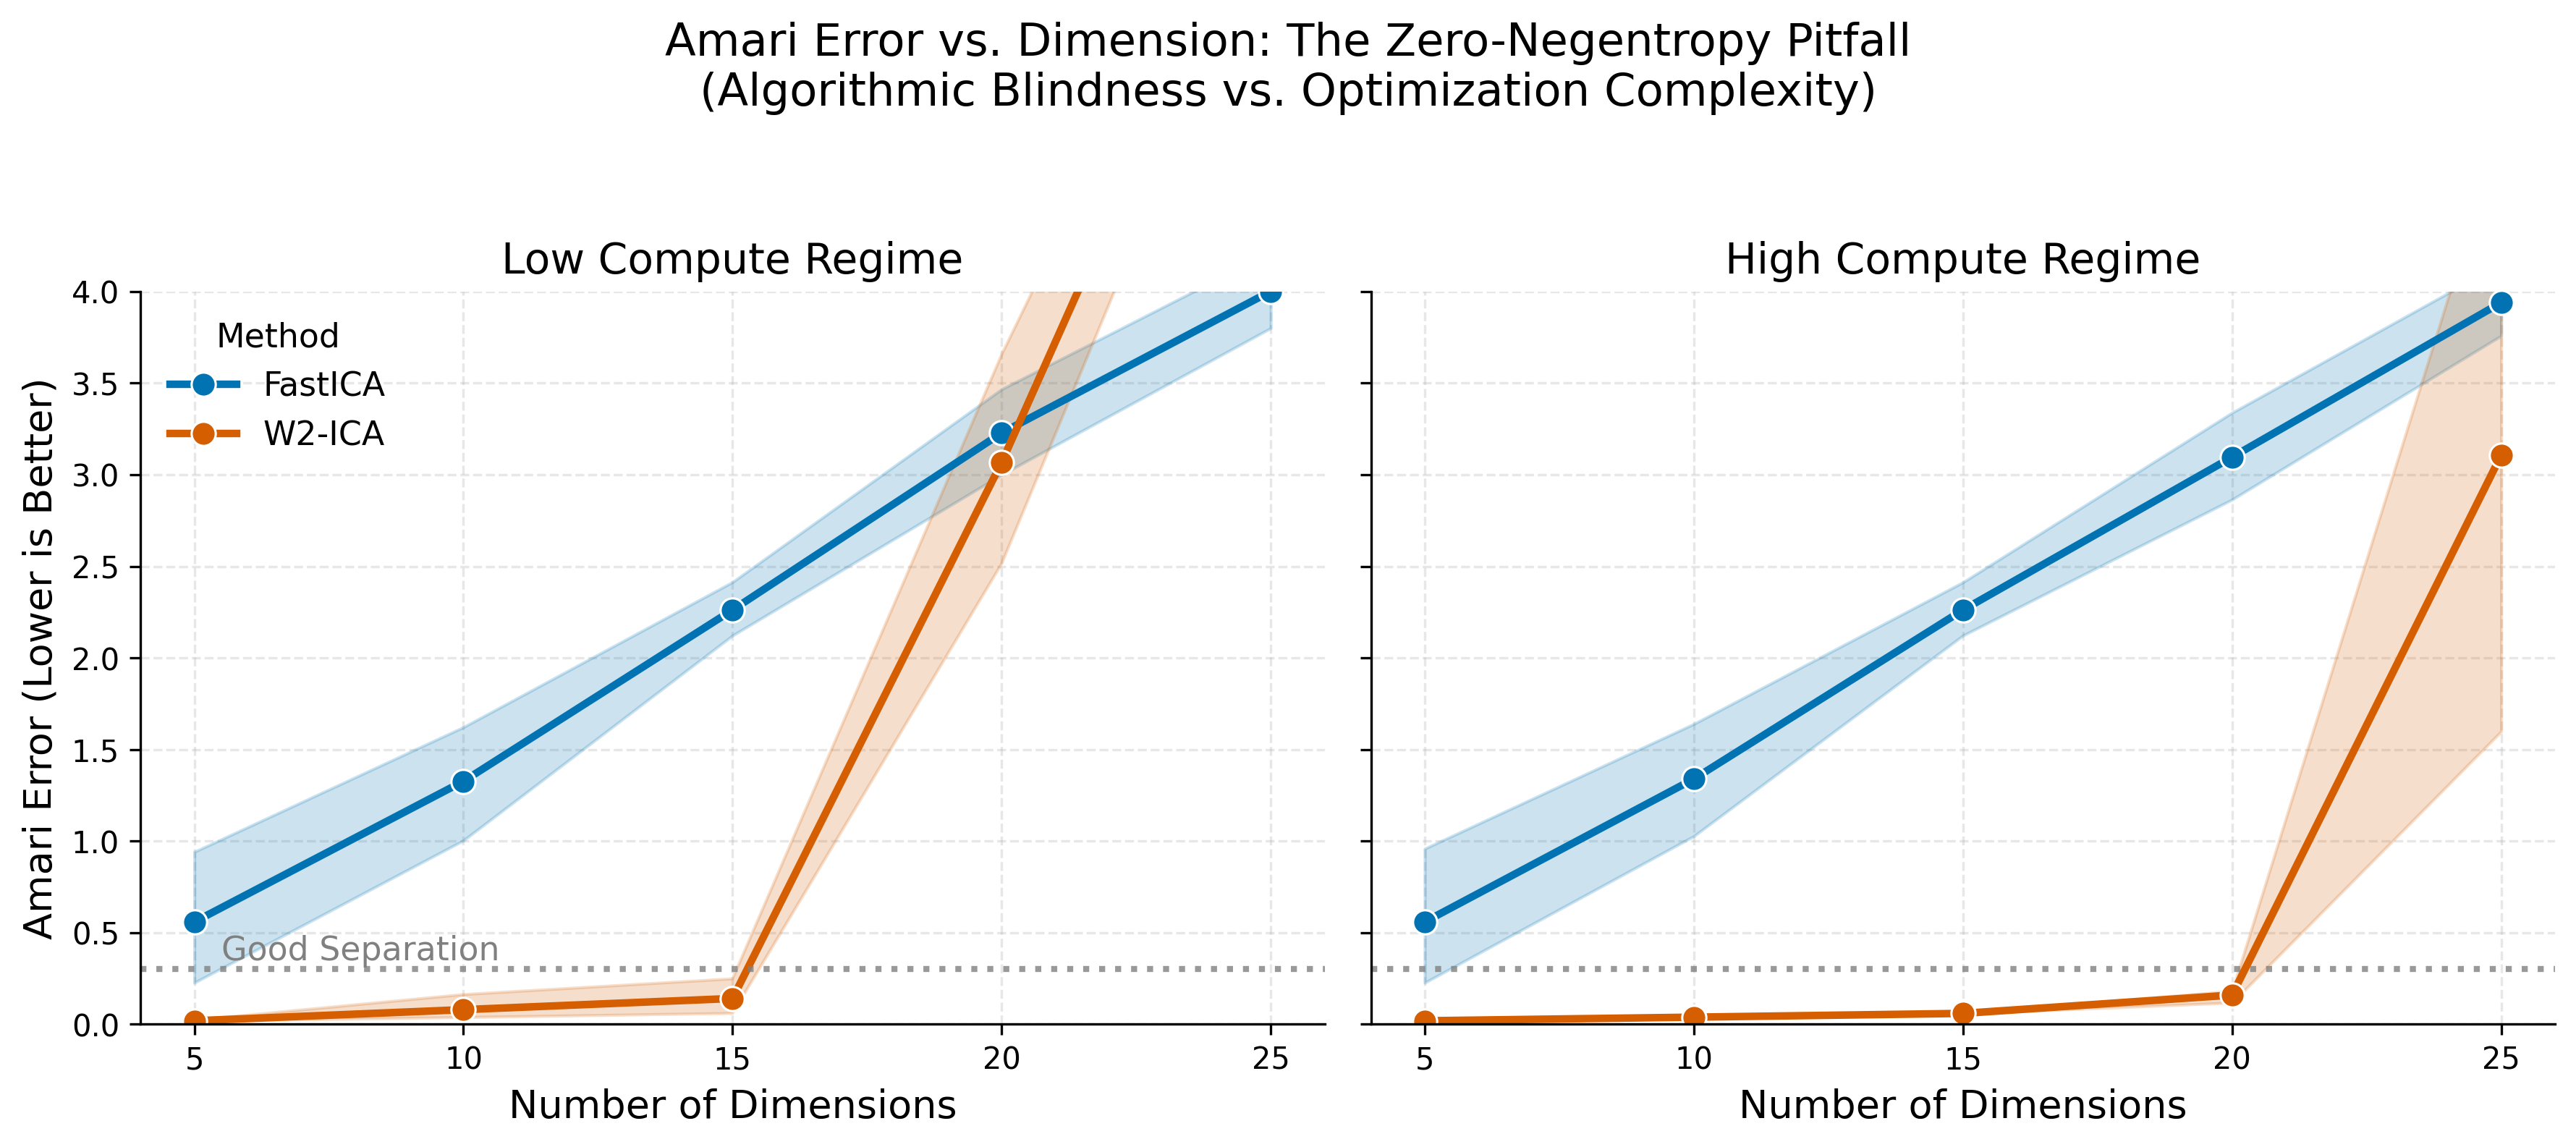

Method             FastICA                   W2-ICA            
Compute Level High Compute Low Compute High Compute Low Compute
Dimension                                                      
5                   0.5582      0.5582       0.0181      0.0181
10                  1.3388      1.3260       0.0379      0.0789
15                  2.2613      2.2615       0.0584      0.1400
20                  3.0960      3.2281       0.1586      3.0676
25                  3.9399      4.0014       3.1069      6.3609

In [40]:
# ==========================================
# 4. Plotting (Side-by-Side 1x2 Layout)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Palette: FastICA is Blue, W2-ICA is Orange
palette = {'FastICA': '#0173B2', 'W2-ICA': '#D55E00'}

# --- Subplot 1: Low Compute ---
df_low = df_phantom[df_phantom['Compute Level'] == 'Low Compute']
sns.lineplot(
    data=df_low, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)
axes[0].set_title("Low Compute Regime", fontsize=14)
axes[0].set_ylabel("Amari Error (Lower is Better)", fontsize=13)
axes[0].set_xlabel("Number of Dimensions", fontsize=13)
axes[0].set_xticks(DIMENSIONS)
axes[0].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)
axes[0].text(5.5, 0.35, 'Good Separation', color='gray', fontsize=11)

handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title='Method', loc='upper left', fontsize=11)

# --- Subplot 2: High Compute ---
df_high = df_phantom[df_phantom['Compute Level'] == 'High Compute']
sns.lineplot(
    data=df_high, 
    x='Dimension', 
    y='Amari Error', 
    hue='Method', 
    palette=palette,
    marker='o', 
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)
axes[1].set_title("High Compute Regime", fontsize=14)
axes[1].set_ylabel("") 
axes[1].set_xlabel("Number of Dimensions", fontsize=13)
axes[1].set_xticks(DIMENSIONS)
axes[1].axhline(0.3, color='gray', linestyle=':', alpha=0.8, linewidth=2)

if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

# --- Global Formatting ---
plt.ylim(0, 4)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5))

fig.suptitle("Amari Error vs. Dimension: The Zero-Negentropy Pitfall\n(Algorithmic Blindness vs. Optimization Complexity)", fontsize=15, y=1.05)

plt.tight_layout()
plt.savefig('zero_negentropy_amari_compute.png', dpi=300, bbox_inches='tight')
plt.show()

summary_table = df_phantom.groupby(['Dimension', 'Method', 'Compute Level'])['Amari Error'].mean().unstack(level=[1,2]).round(4)
display(summary_table)